In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# CH12-Q10
<h2>
In this problem, you will generate simulated data, and then perform PCA and K-means clustering on the data.
<h2>

### (a) Generate a simulated data set with 20 observations in each of three classes (i.e. 60 observations total), and 50 variables. 

<h4>
Hint: There are a number of functions in Python that you can use to generate data. One example is the normal() method of the random() function in numpy; the uniform() method is another option. Be sure to add a mean shift to the observations in each class so that there are three distinct classes.


In [12]:
classes = 3
classes_n = 20
variables = 50

data = []
label = []

for i in range(classes):
    mean_shift = i * 3.0
    X = np.random.normal(loc=mean_shift, scale=1.0, size=(classes_n, variables))
    
    data.append(X)
    label += [i] * classes_n

X_total = np.vstack(data)
y_total = np.array(label)


df = pd.DataFrame(X_total, columns=[f"X{j+1}" for j in range(variables)])
df["class"] = y_total

In [14]:
df

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X42,X43,X44,X45,X46,X47,X48,X49,X50,class
0,-0.347019,0.161222,1.790938,-0.960931,-1.018567,1.291878,-1.031458,-0.444319,-0.566871,0.573924,...,-1.036185,0.360443,-1.062378,0.933412,-1.234226,0.410810,0.091456,1.060713,-0.640058,0
1,-1.825866,0.642403,-0.671694,0.233084,-0.395816,-0.555044,-0.154857,0.515904,0.765098,0.107330,...,-1.366235,-0.753788,-0.745678,-0.575887,0.551543,-1.402196,-0.580063,-0.182673,0.521941,0
2,0.429404,0.080360,0.679703,-0.365983,-0.107316,-1.096795,0.605956,-0.636504,0.171778,0.084797,...,0.098020,-0.214073,0.387660,-1.091976,-0.920369,-2.142166,0.546047,-0.240766,0.163174,0
3,1.946193,-0.787087,-0.224629,0.356782,0.043303,0.459959,1.390511,0.475297,0.458903,-1.228875,...,-0.082652,0.104228,0.601870,-1.894834,1.671618,-0.046212,-0.785711,0.094441,0.544946,0
4,0.053188,0.507318,0.047619,-1.069779,-0.946445,0.553803,-1.015406,-0.042651,2.404387,0.234746,...,0.159008,1.395151,-1.283929,0.713609,0.134674,2.249838,0.411071,0.900905,0.067888,0
5,0.580285,0.075854,1.173600,-0.108694,1.229819,0.516993,-0.189598,0.309589,-0.745649,1.600010,...,1.474322,-0.881199,-0.752521,1.095601,0.618465,-0.702769,-0.569370,2.098389,-0.165826,0
6,-0.497124,-1.960361,0.101854,0.556285,0.124193,-0.714377,-0.133428,-0.431446,-1.203053,0.476221,...,-0.778257,-1.113732,-0.079608,-1.979021,-1.175621,0.414942,1.177420,-0.087330,1.251520,0
7,-0.354023,-0.525889,0.385656,-0.213013,-0.131432,0.321691,-0.647375,-0.610295,0.151256,-0.383001,...,0.152401,-0.353196,-0.767370,-1.483502,-1.244436,-2.031613,0.067108,1.785057,0.199563,0
8,0.253701,-0.427365,-0.946487,1.074044,1.642879,1.787666,-0.092902,-0.394853,0.930861,-0.099353,...,-0.649253,-0.547337,0.682616,0.267137,0.045213,-0.131435,0.860570,0.124403,-0.536773,0
9,-0.265754,0.529650,-0.392073,-1.994194,1.551358,-0.023196,-0.310168,-0.524679,1.220414,-0.467479,...,1.478948,0.634525,-0.768984,-0.573511,-1.635150,-2.695571,-0.031752,-0.692125,0.090091,0


### (b) Perform PCA on the 60 observations and plot the first two principal component score vectors. Use a different color to indicate the observations in each of the three classes. 
<h4>
If the three classes appear separated in this plot, then continue on to part (c). If not, then return to part (a) and modify the simulation so that there is greater separation between the three classes. Do not continue to part (c) until the three classes show at least some separation in the first two principal component score vectors.

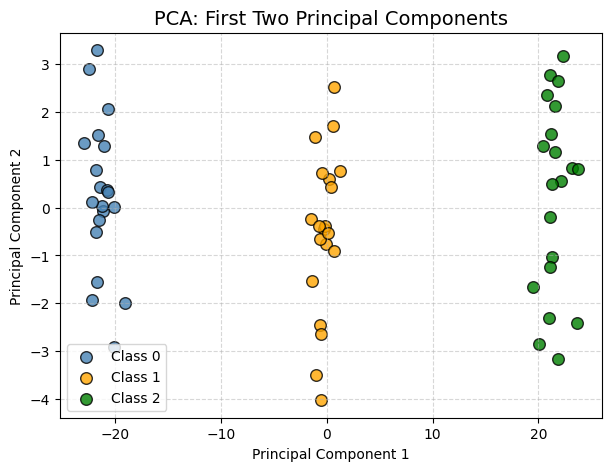

In [15]:
X = df.drop(columns="class").values
y = df["class"].values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "class": y
})

plt.figure(figsize=(7, 5))
colors = ['steelblue', 'orange', 'green']
for i, color in enumerate(colors):
    subset = df_pca[df_pca["class"] == i]
    plt.scatter(subset["PC1"], subset["PC2"], 
                color=color, label=f"Class {i}", 
                s=70, edgecolor="black", alpha=0.8)

plt.title("PCA: First Two Principal Components", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### (c) Perform K-means clustering of the observations with K = 3. How well do the clusters that you obtained in K-means clustering compare to the true class labels?
<h4>
Hint: You can use the pd.crosstab() function in Python to compare the true class labels to the class labels obtained by clustering. 
Be careful how you interpret the results: K-means clustering will arbitrarily number the clusters, so you cannot simply check
whether the true class labels and clustering labels are the same.

In [16]:
from sklearn.cluster import KMeans

In [ ]:
X = df.drop(columns="class").values
y_true = df["class"].values

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

y_kmeans = kmeans.labels_

comparison = pd.crosstab(y_true, y_kmeans,
                         rownames=['True Class'],
                         colnames=['K-means Cluster'])
print(comparison)

K-means Cluster   0   1   2
True Class                 
0                 0   0  20
1                20   0   0
2                 0  20   0


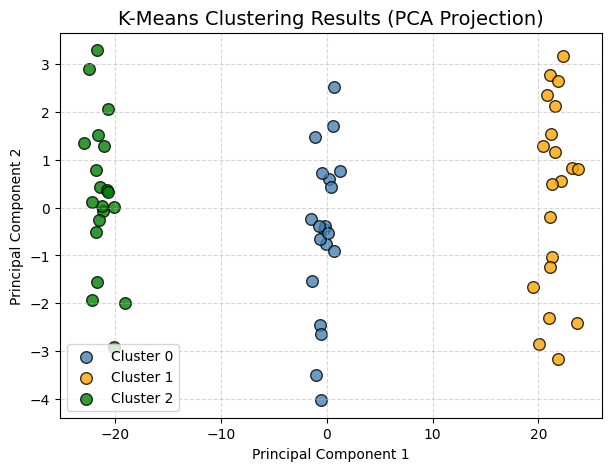

In [20]:
X = df.drop(columns="class").values
y_true = df["class"].values

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": y_kmeans
})


plt.figure(figsize=(7, 5))
colors = ['steelblue', 'orange', 'green']
for i, color in enumerate(colors):
    subset = df_pca[df_pca["cluster"] == i]
    plt.scatter(subset["PC1"], subset["PC2"], 
                color=color, label=f"Cluster {i}", 
                s=70, edgecolor="black", alpha=0.8)

plt.title("K-Means Clustering Results (PCA Projection)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### (d) Perform K-means clustering with K = 2. Describe your results.

Use k-means to divide 3 clusters into 2 clusters, new cluster 0 includes 2 clusters, which are cluster 0 and cluster 2 originally, dividing into 3 clusters by k-means in (c)

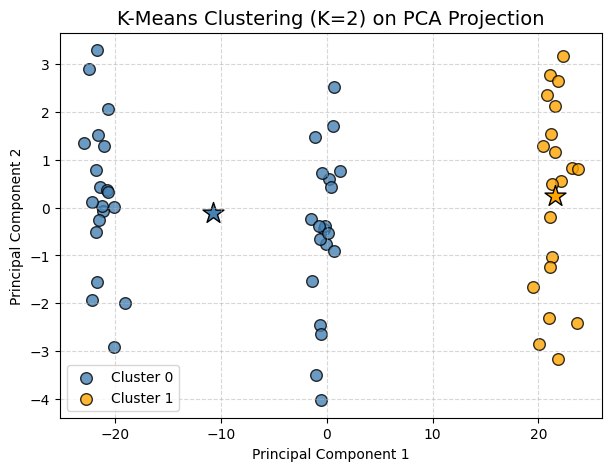

In [38]:
X = df.drop(columns="class").values
y_true = df["class"].values

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": y_kmeans
})

centers_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(7, 5))
colors = ['steelblue', 'orange']
for i, color in enumerate(colors):
    subset = df_pca[df_pca["cluster"] == i]
    plt.scatter(subset["PC1"], subset["PC2"], 
                color=color, label=f"Cluster {i}", 
                s=70, edgecolor="black", alpha=0.8)

# 每個群的中心點（centroids）
for i, (x, y) in enumerate(centers_pca):
    plt.scatter(x, y, marker="*", s=250, color=colors[i], edgecolor="black")

plt.title("K-Means Clustering (K=2) on PCA Projection", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [39]:
comparison = pd.crosstab(y_true, y_kmeans,
                         rownames=['True Class'],
                         colnames=['K-means Cluster'])
print(comparison)

K-means Cluster   0   1
True Class             
0                20   0
1                20   0
2                 0  20


### (e) Now perform K-means clustering with K = 4, and describe your results.

Use k-means to divide 3 clusters into 4 clusters. A new cluster is divided by one of the clusters, and not split very clearly

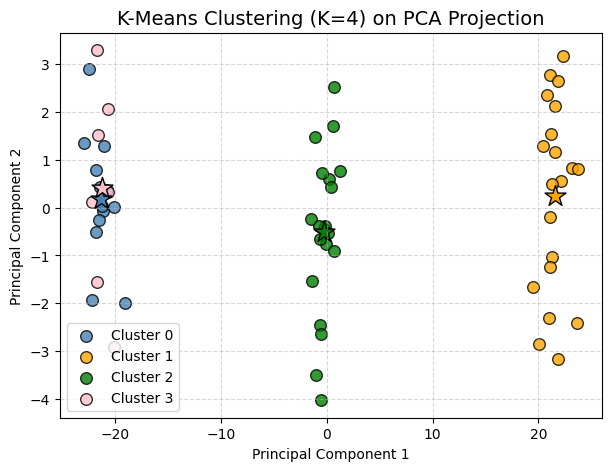

In [40]:
X = df.drop(columns="class").values
y_true = df["class"].values

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": y_kmeans
})

centers_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(7, 5))
colors = ['steelblue', 'orange', 'green', 'pink']
for i, color in enumerate(colors):
    subset = df_pca[df_pca["cluster"] == i]
    plt.scatter(subset["PC1"], subset["PC2"], 
                color=color, label=f"Cluster {i}", 
                s=70, edgecolor="black", alpha=0.8)

# 每個群的中心點（centroids）
for i, (x, y) in enumerate(centers_pca):
    plt.scatter(x, y, marker="*", s=250, color=colors[i], edgecolor="black")

plt.title("K-Means Clustering (K=4) on PCA Projection", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [41]:
comparison = pd.crosstab(y_true, y_kmeans,
                         rownames=['True Class'],
                         colnames=['K-means Cluster'])
print(comparison)

K-means Cluster   0   1   2  3
True Class                    
0                13   0   0  7
1                 0   0  20  0
2                 0  20   0  0


### (f) Now perform K-means clustering with K = 3 on the first two principal component score vectors, rather than on the raw data. That is, perform K-means clustering on the 60 × 2 matrix of which the first column is the first principal component score vector, and the second column is the second principal component score vector. Comment on the results.

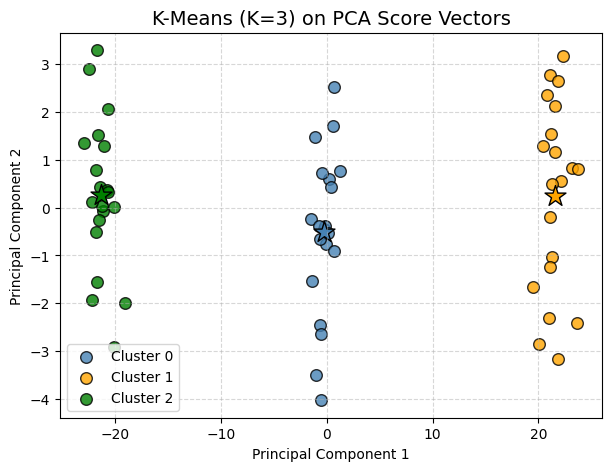

K-means (on PCA) Cluster   0   1   2
True Class                          
0                          0   0  20
1                         20   0   0
2                          0  20   0


In [53]:
X = df.drop(columns="class").values
y_true = df["class"].values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans_pca = kmeans_pca.fit_predict(X_pca)

df_pca_kmeans = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": y_kmeans_pca
})

centers_pca = kmeans_pca.cluster_centers_
plt.figure(figsize=(7,5))
colors = ['steelblue', 'orange', 'green']
for i, color in enumerate(colors):
    subset = df_pca_kmeans[df_pca_kmeans["cluster"] == i]
    plt.scatter(subset["PC1"], subset["PC2"], 
                color=color, label=f"Cluster {i}", 
                s=70, edgecolor="black", alpha=0.8)



for i, (x, y) in enumerate(centers_pca):
    plt.scatter(x, y, marker="*", s=250, color=colors[i], edgecolor="black")

plt.title("K-Means (K=3) on PCA Score Vectors", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


comparison_pca = pd.crosstab(y_true, y_kmeans_pca,
                             rownames=['True Class'],
                             colnames=['K-means (on PCA) Cluster'])
print(comparison_pca)

### (g) Using the StandardScaler() estimator, perform K-means clustering with K = 3 on the data after scaling each variable to have standard deviation one. How do these results compare to those obtained in (b)? Explain.

The first two principal components likely capture the majority of the variation that distinguishes the clusters. Variables with larger numerical ranges dominated the PCA and K-means results, causing clusters to reflect mainly magnitude differences. After scaling all variables contributed equally, and producing more balanced and meaningful clusters

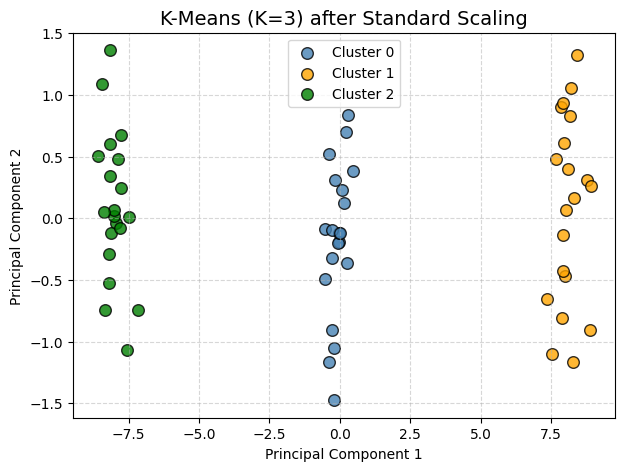

K-means Cluster (Scaled)   0   1   2
True Class                          
0                          0   0  20
1                         20   0   0
2                          0  20   0


In [54]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns="class").values
y_true = df["class"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans_scaled = kmeans_scaled.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca_scaled = pca.fit_transform(X_scaled)

df_scaled_pca = pd.DataFrame({
    "PC1": X_pca_scaled[:, 0],
    "PC2": X_pca_scaled[:, 1],
    "cluster": y_kmeans_scaled
})

plt.figure(figsize=(7, 5))
colors = ['steelblue', 'orange', 'green']
for i, color in enumerate(colors):
    subset = df_scaled_pca[df_scaled_pca["cluster"] == i]
    plt.scatter(subset["PC1"], subset["PC2"],
                color=color, label=f"Cluster {i}",
                s=70, edgecolor="black", alpha=0.8)


plt.title("K-Means (K=3) after Standard Scaling", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 7️⃣ Compare clusters with true classes
comparison_scaled = pd.crosstab(y_true, y_kmeans_scaled,
                                 rownames=['True Class'],
                                 colnames=['K-means Cluster (Scaled)'])
print(comparison_scaled)

# CH4-Q9 p129
<h3>
This question involves the use of multiple linear regression on the Auto data set.

In [14]:
df = pd.read_csv('Auto.csv', na_values='?')
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
394,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
395,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.0+ KB


### (a) Produce a scatterplot matrix which includes all of the variables in the data set.

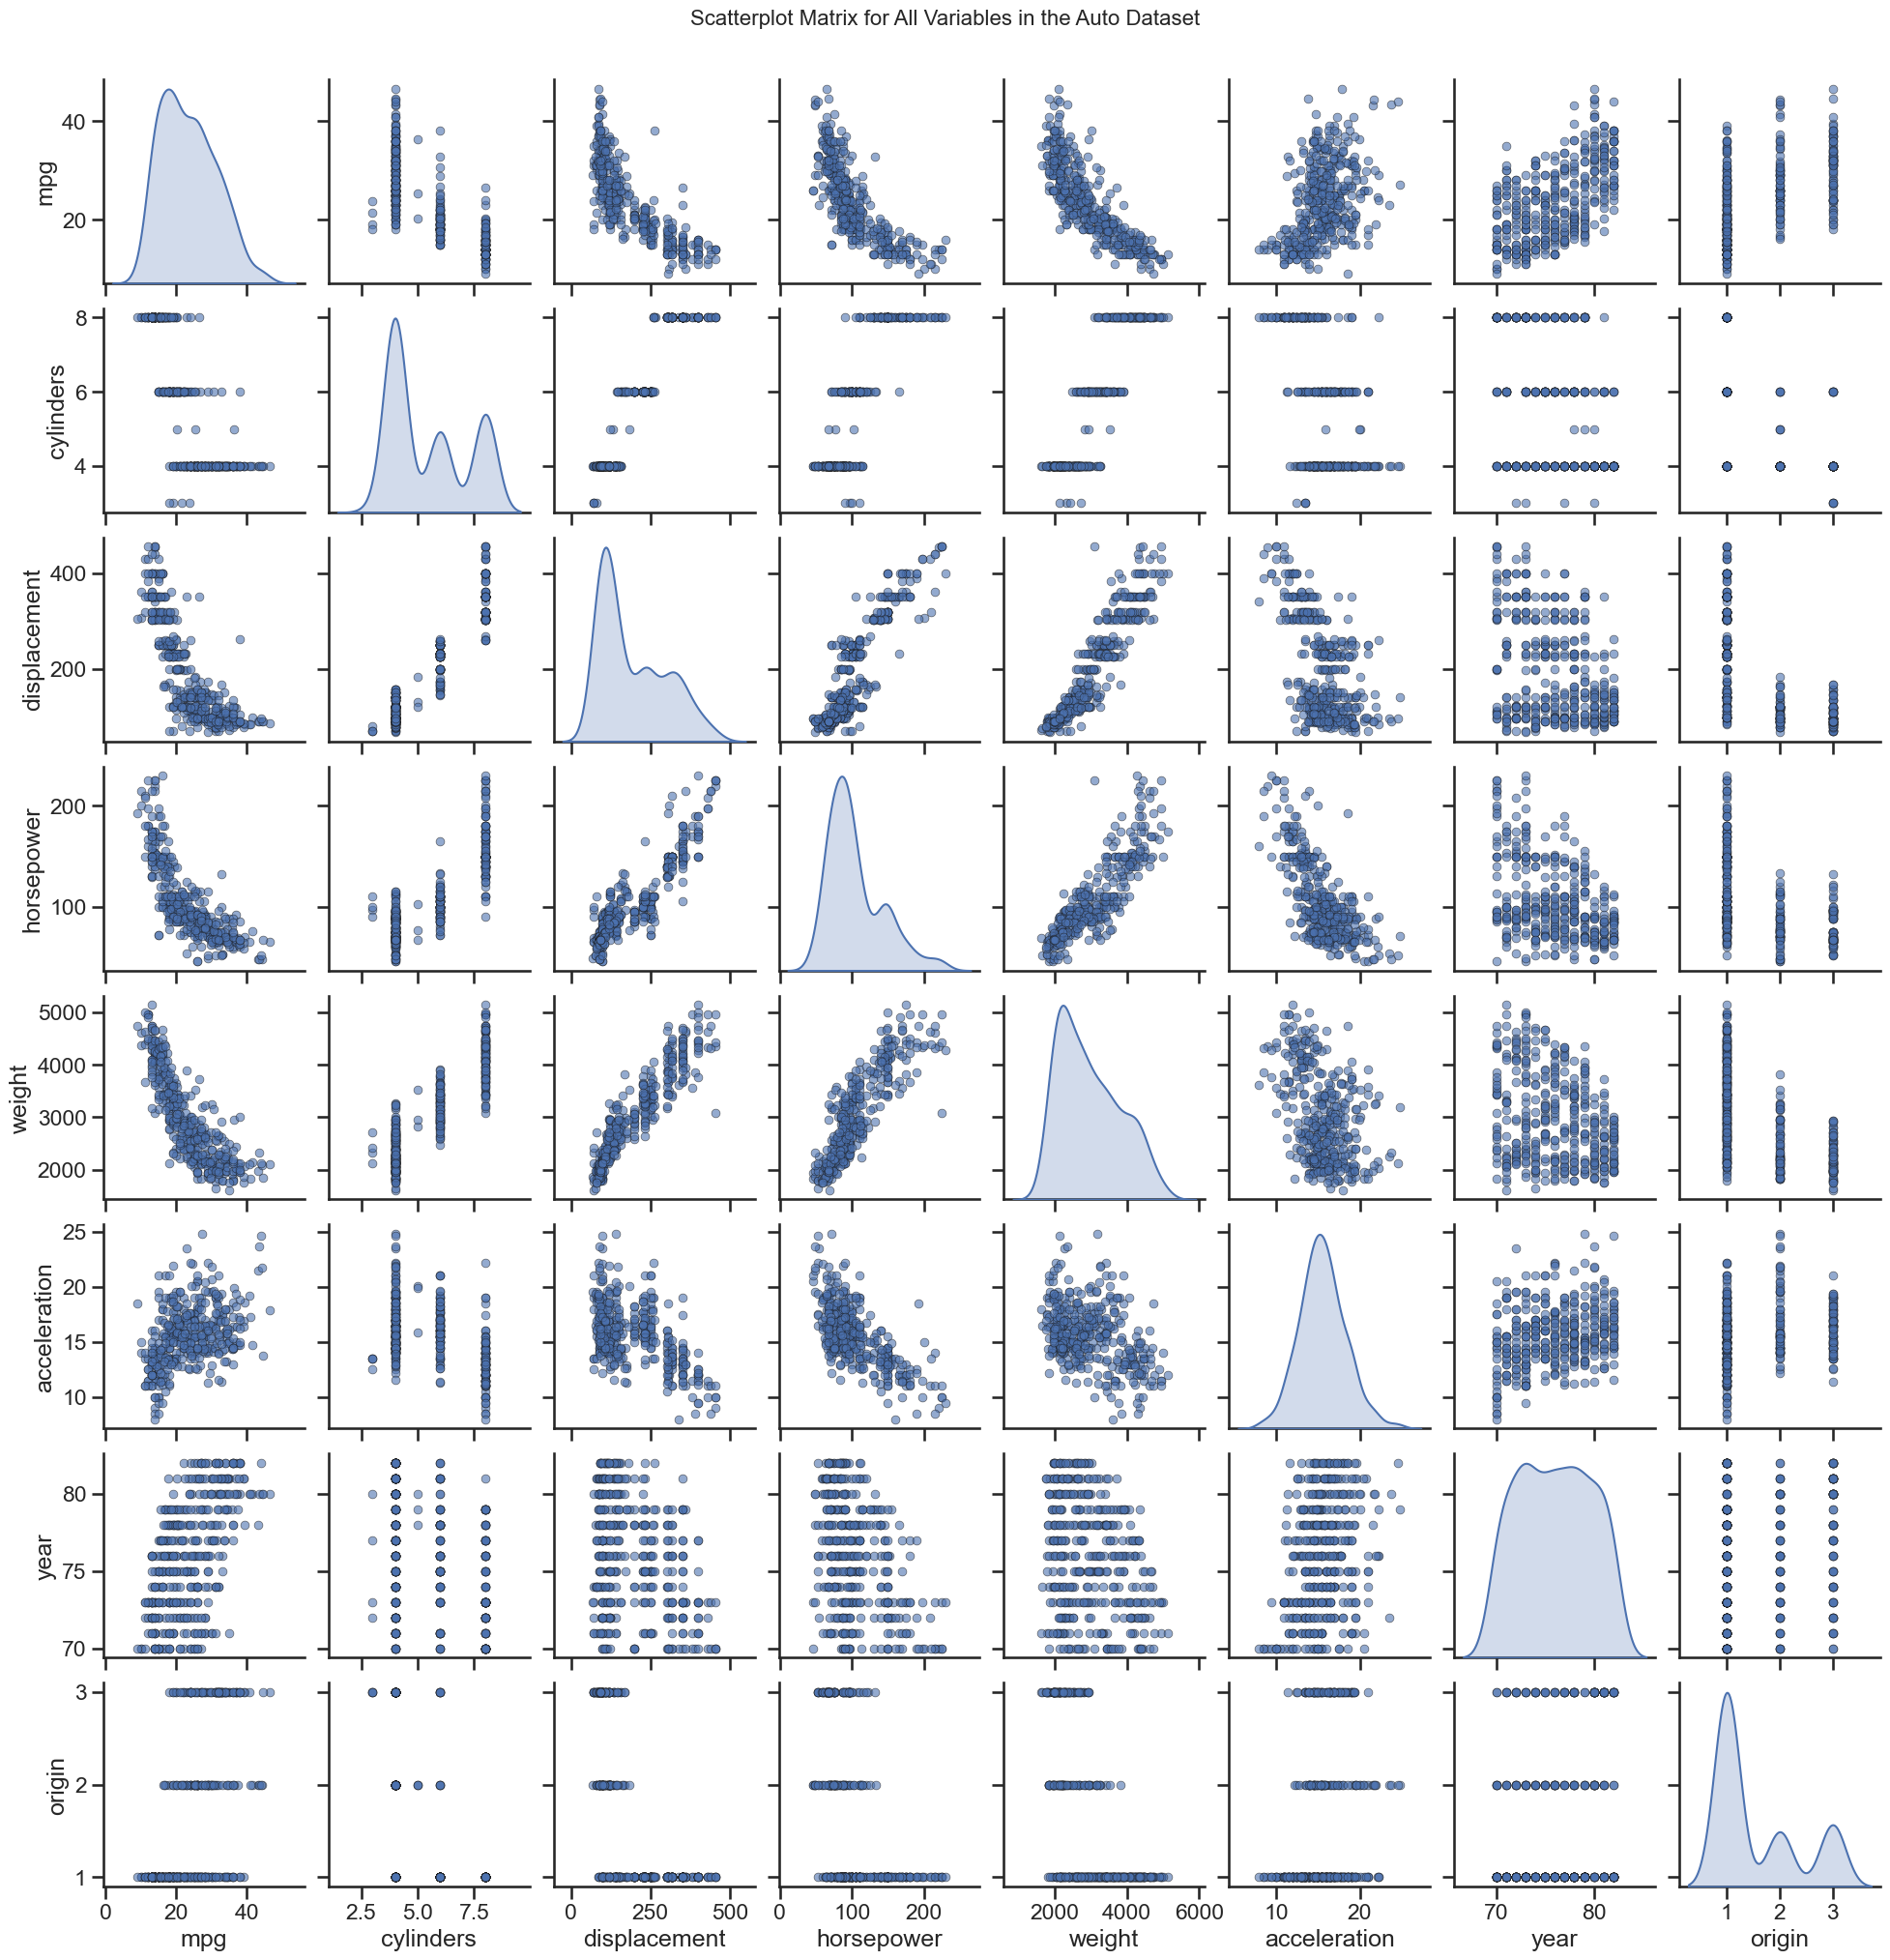

In [16]:
import seaborn as sns

sns.set(style='ticks', context='talk')
sns.pairplot(df, diag_kind="kde", plot_kws={'alpha':0.6, 's':40, 'edgecolor':'k'})
plt.suptitle("Scatterplot Matrix for All Variables in the Auto Dataset", y=1.02, fontsize=16)
plt.show()

### (b) Compute the matrix of correlations between the variables using the DataFrame.corr() method.

In [20]:
corr = df.drop(columns=['name']).corr()

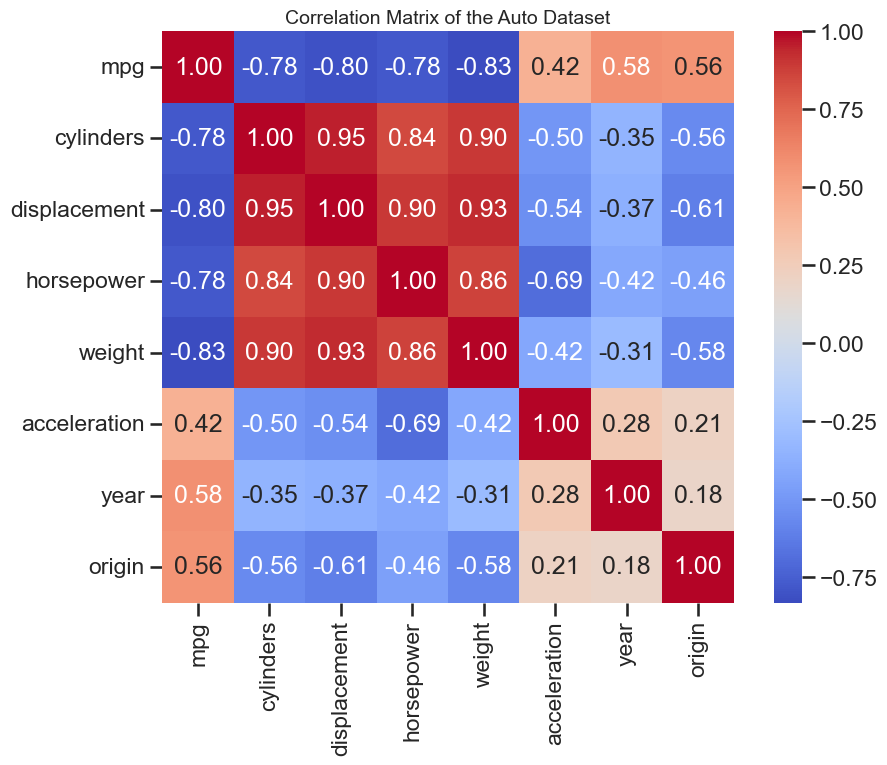

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title('Correlation Matrix of the Auto Dataset', fontsize=14)
plt.tight_layout()
plt.show()

### (c) Use the sm.OLS() function to perform a multiple linear regression with mpg as the response and all other variables except name as the predictors. Use the summarize() function to print the results. Comment on the output. For instance:

In [23]:
import statsmodels.api as sm
df['horsepower'] = df['horsepower'].fillna(0)

y = df['mpg']
X = df.drop(columns=['mpg', 'name'])

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     257.0
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          1.28e-141
Time:                        01:00:20   Log-Likelihood:                -1036.8
No. Observations:                 397   AIC:                             2090.
Df Residuals:                     389   BIC:                             2121.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.9640      4.449     -4.038   

<h4>
i. Is there a relationship between the predictors and the response? Use the anova_lm() function from statsmodels to answer this question.

In [27]:
from statsmodels.stats.anova import anova_lm
import statsmodels.formula.api as smf

formula = 'mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin'
model = smf.ols(formula, data=df).fit()

anova = anova_lm(model)
pd.options.display.float_format = '{:.6f}'.format
print(anova)

                     df       sum_sq      mean_sq           F   PR(>F)
cylinders      1.000000 14613.945015 14613.945015 1318.435006 0.000000
displacement   1.000000  1112.755282  1112.755282  100.390108 0.000000
horsepower     1.000000   340.926612   340.926612   30.757580 0.000000
weight         1.000000  1033.803311  1033.803311   93.267251 0.000000
acceleration   1.000000     0.590658     0.590658    0.053288 0.817559
year           1.000000  2536.727736  2536.727736  228.857481 0.000000
origin         1.000000   301.764027   301.764027   27.224425 0.000000
Residual     389.000000  4311.797385    11.084312         NaN      NaN


The ANOVA results show cylinders, displacement, horsepower, weight, year, and origin have very large F-statistics with p-values near zero.
mpg has a strong relationship among these predictor, only acceleration is not statistically significant.

<h4>ii. Which predictors appear to have a statistically significant relationship to the response?

cylinders, displacement, horsepower, weight, year, and origin have a statistically significant relationship to the response

<h4>iii. What does the coefficient for the year variable suggest?

The coefficient of the year is approximately 0.75, it means mpg increases by 0.75 for each additional year, and holding other predictors constant. 

### (d) Produce some of diagnostic plots of the linear regression fit as described in the lab. Comment on any problems you see with the fit. Do the residual plots suggest any unusually large outliers? Does the leverage plot identify any observations with unusually high leverage?

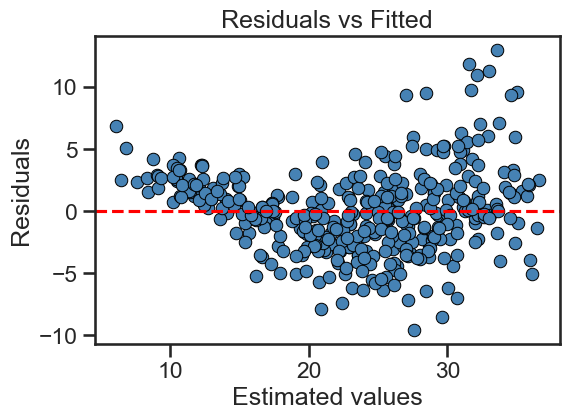

In [42]:
fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals, color="steelblue", edgecolor="black")
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Estimated values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

x axis is estimated value, y axis is residuals(actual-estimated)
there is no cruve in this plot, but as the residuals increase with estimated values.

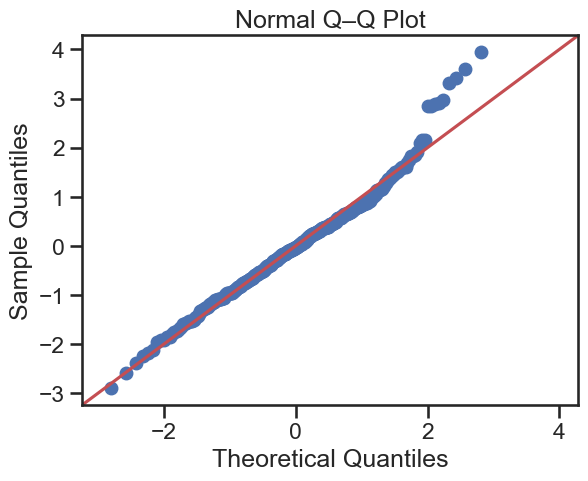

In [29]:
sm.qqplot(residuals, line='45', fit=True)
plt.title("Normal Q–Q Plot")
plt.show()

The normal Q–Q plot shows the overall residuals are approximately normal, and the points distributes falling on the 45 degree upward straight line, but a few points deviate from the red line at the tail end, and there may be outlier values.

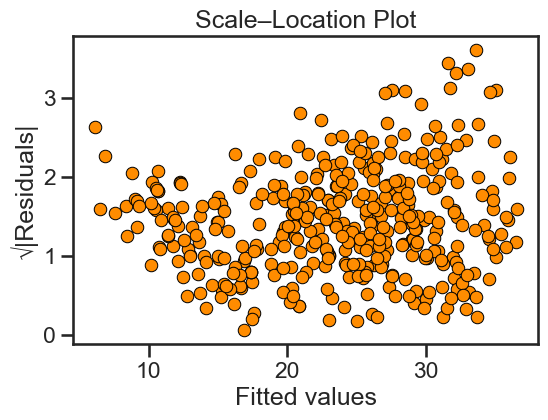

In [30]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=abs(residuals)**0.5, color="darkorange", edgecolor="black")
plt.xlabel("Fitted values")
plt.ylabel("√|Residuals|")
plt.title("Scale–Location Plot")
plt.show()

The square root of the absolute value of the residual increases with the estimated value, which may indicate heterogeneous variation.

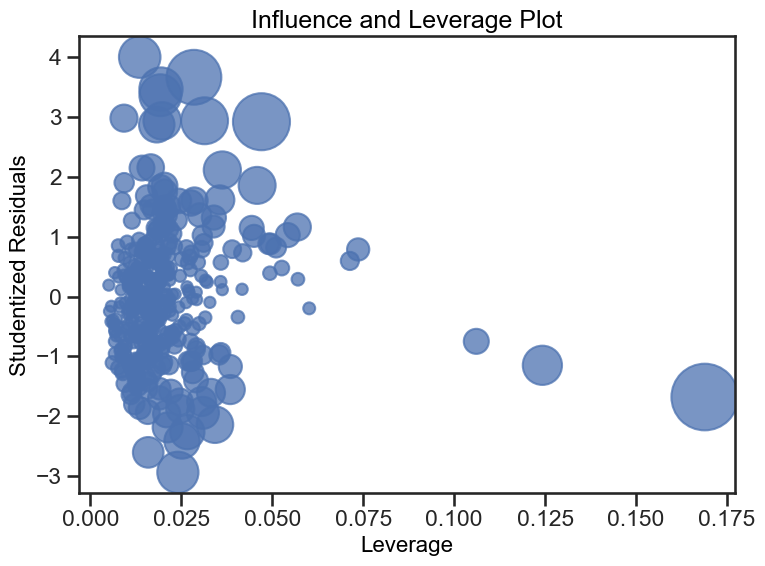

In [43]:
fig, ax = plt.subplots(figsize=(8, 6))
sm.graphics.influence_plot(model, criterion="cooks", ax=ax, alpha=0.7, fontsize=0)

plt.title("Influence and Leverage Plot")
for text in ax.texts:
    text.set_visible(False)

plt.tight_layout()
plt.show()

The leverage plot identifies a few observations with relatively high leverage.
None of these points appear to have excessively large Cook’s distances, so they are not unduly influential on the model fit.

### (e) Fit some models with interactions as described in the lab. Do any interactions appear to be statistically significant?

In [46]:
interact = """
mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin
      + horsepower*weight + year*origin + displacement*cylinders
"""
model_interact = smf.ols(interact, data=df).fit()

print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     241.4
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          2.81e-159
Time:                        01:55:13   Log-Likelihood:                -986.31
No. Observations:                 397   AIC:                             1995.
Df Residuals:                     386   BIC:                             2038.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 15

horsepower*weight, year*origin, and displacement*cylinders are statistically significant to the response.

### (f) Try a few different transformations of the variables, such as log(X), √X, and X².  Comment on your findings.



In [47]:
# log
num_cols = df.select_dtypes(include=[np.number]).columns.drop('mpg')
df_log = df.copy()

for col in num_cols:
    min_val = df_log[col].min()
    if min_val <= 0:
        shift = abs(min_val) + 1
    else:
        shift = 1
    df_log[f'log_{col}'] = np.log(df_log[col] + shift)

formula_log = 'mpg ~ ' + ' + '.join([f'log_{col}' for col in num_cols])
model_log = smf.ols(formula_log, data=df_log).fit()
print("=== Log-transformed model ===")
print(model_log.summary())

=== Log-transformed model ===
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     296.7
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          1.05e-151
Time:                        02:01:25   Log-Likelihood:                -1013.0
No. Observations:                 397   AIC:                             2042.
Df Residuals:                     389   BIC:                             2074.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept 

In [49]:
# square root
df_sqrt = df.copy()
for col in num_cols:
    df_sqrt[f'sqrt_{col}'] = np.sqrt(df_sqrt[col])

formula_sqrt = 'mpg ~ ' + ' + '.join([f'sqrt_{col}' for col in num_cols])
model_sqrt = smf.ols(formula_sqrt, data=df_sqrt).fit()
print("\n=== Sqrt-transformed model ===")
print(model_sqrt.summary())


=== Sqrt-transformed model ===
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     277.9
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          4.41e-147
Time:                        02:02:50   Log-Likelihood:                -1023.9
No. Observations:                 397   AIC:                             2064.
Df Residuals:                     389   BIC:                             2096.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Interc

In [50]:
# square
df_sq = df.copy()
for col in num_cols:
    df_sq[f'{col}_sq'] = df_sq[col] ** 2

formula_sq = 'mpg ~ ' + ' + '.join([f'{col}_sq' for col in num_cols])
model_sq = smf.ols(formula_sq, data=df_sq).fit()
print("\n=== Squared model ===")
print(model_sq.summary())



=== Squared model ===
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.798
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     219.5
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          7.40e-131
Time:                        02:02:55   Log-Likelihood:                -1062.1
No. Observations:                 397   AIC:                             2140.
Df Residuals:                     389   BIC:                             2172.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          

In [52]:
compare = pd.DataFrame({
    "Model": ["Log(X)", "√X", "X²"],
    "Adj. R²": [model_log.rsquared_adj, model_sqrt.rsquared_adj, model_sq.rsquared_adj],
    "AIC": [model_log.aic, model_sqrt.aic, model_sq.aic],
    "BIC": [model_log.bic, model_sqrt.bic, model_sq.bic]
})

pd.options.display.float_format = '{:.4f}'.format
print("\n Model Comparison:")
print(compare)


 Model Comparison:
    Model  Adj. R²       AIC       BIC
0  Log(X)   0.8394 2042.0422 2073.9137
1      √X   0.8304 2063.8167 2095.6882
2      X²   0.7943 2140.2890 2172.1605


after log transformation model gain the best performance because there are the highest R^2, the lowest AIC and BIC on the result. Log transformation make model more stabilizing and linearity

the square root model provides moderate improvement and square model gain the worst performance with the lowest R^2, the highest AIC and BIC

# CH4-Q15 p133
<h3>
This problem involves the Boston data set, which we saw in the lab for this chapter. We will now try to predict per capita crime rate using the other variables in this data set. In other words, per capita crime rate is the response, and the other variables are the predictors.

### (a) For each predictor, fit a simple linear regression model to predict the response. Describe your results. In which of the models is there a statistically significant association between the predictor and the response? Create some plots to back up your assertions.

In [12]:
from ISLP import load_data
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

boston = load_data("Boston")

In [7]:
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


All Regression Results:

   Predictor  Coefficient  P-value  R-squared
7        rad     0.617911 0.000000   0.391257
8        tax     0.029742 0.000000   0.339614
10     lstat     0.548805 0.000000   0.207591
3        nox    31.248531 0.000000   0.177217
1      indus     0.509776 0.000000   0.165310
11      medv    -0.363160 0.000000   0.150780
6        dis    -1.550902 0.000000   0.144149
5        age     0.107786 0.000000   0.124421
9    ptratio     1.151983 0.000000   0.084068
4         rm    -2.684051 0.000001   0.048069
0         zn    -0.073935 0.000006   0.040188
2       chas    -1.892777 0.209435   0.003124


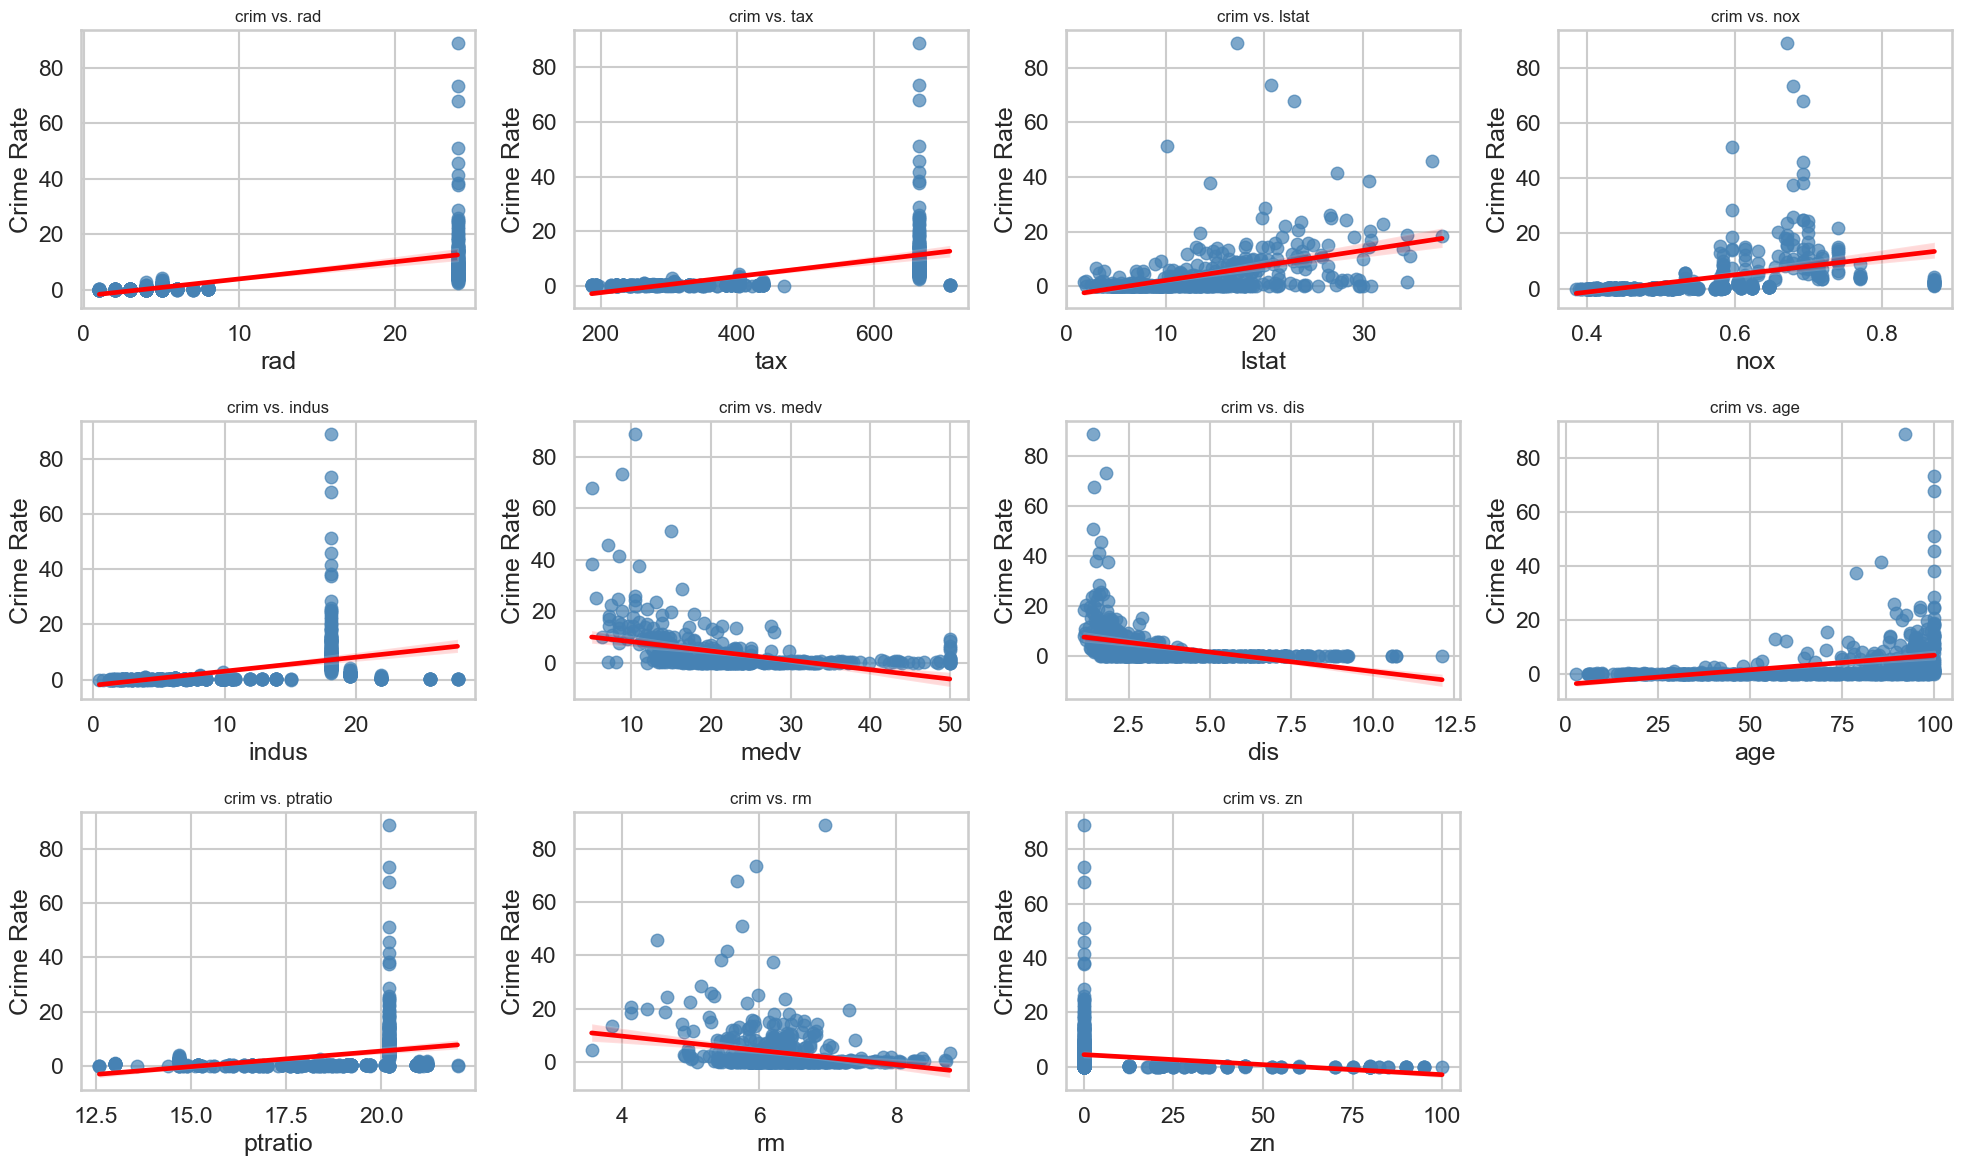

In [15]:
y = boston["crim"]

results = []

for col in boston.columns:
    if col == "crim":
        continue
    x = sm.add_constant(boston[col])
    model = sm.OLS(y, x).fit()
    
    results.append({
        "Predictor": col,
        "Coefficient": model.params[col],
        "P-value": model.pvalues[col],
        "R-squared": model.rsquared
    })

results_df = pd.DataFrame(results)
pd.options.display.float_format = '{:.6f}'.format
print("All Regression Results:\n")
print(results_df.sort_values("P-value"))


significant = results_df[results_df["P-value"] < 0.05].sort_values("P-value")
sns.set(style="whitegrid", context="talk")

sig_vars = list(significant["Predictor"])
n = len(sig_vars)
cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

for i, col in enumerate(sig_vars):
    sns.regplot(
        x=boston[col], y=boston["crim"],
        scatter_kws={'alpha':0.7, 'color':'steelblue'},
        line_kws={'color':'red'},
        ax=axes[i]
    )
    axes[i].set_title(f"crim vs. {col}", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Crime Rate")
    
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

almost predictors show statistically significant associations with the per capita crime rate except chas (p < 0.05)

see these scatterplot, rad, tax, lstat, nox, indus, age and ptratio have strong positive relationships with crime, while medv, dis, rm and zn shows a negative relationship. 

and these scatterplot showing align with the regression coefficients and p-values, supporting the existence of meaningful linear associations between these predictors and the response.

### (b) Fit a multiple regression model to predict the response using all of the predictors.  Describe your results. For which predictors can we reject the null hypothesis $H_0 : \beta_j = 0$ ?

In [16]:
y = boston["crim"]
x = boston.drop(columns=["crim"])
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Wed, 15 Oct 2025   Prob (F-statistic):           2.03e-56
Time:                        02:20:38   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.7784      7.082      1.946      0.0

In [17]:
significant_predictors = model.pvalues[model.pvalues < 0.05]
print("Predictors with p < 0.05:")
print(significant_predictors)

Predictors with p < 0.05:
zn     0.015344
dis    0.000373
rad    0.000000
medv   0.000261
dtype: float64


zn, dis, rad, and medv predictors have p-values below 0.05 that these predictors can reject the null hypothesis.

### (c) How do your results from (a) compare to your results from (b)? 
<h4>
Create a plot displaying the univariate regression coefficients from (a) on the x-axis, and the multiple regression coefficients from (b) on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate in the multiple linear regression model is shown on the y-axis.

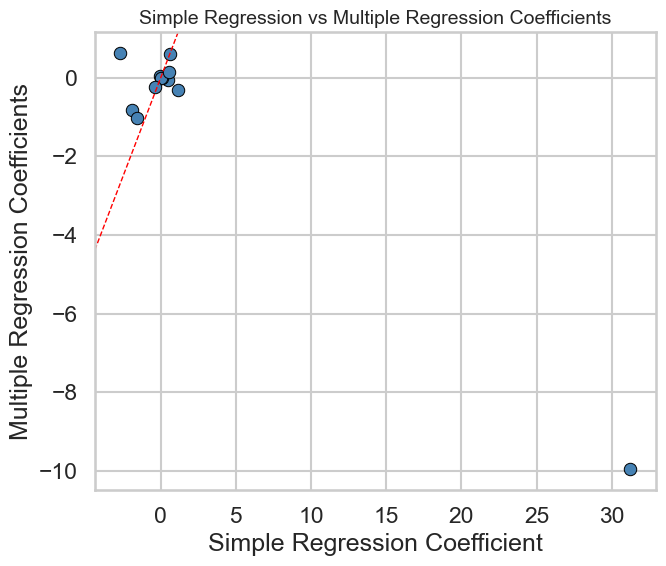

In [22]:
uni_results = []
for col in boston.columns:
    if col == "crim":
        continue
    X_uni = sm.add_constant(boston[col])
    model_uni = sm.OLS(y, X_uni).fit()
    uni_results.append({
        "Predictor": col,
        "Univariate_Coeff": model_uni.params[col]
    })
uni_df = pd.DataFrame(uni_results)

# Multiple regression (all predictors together)
X_multi = sm.add_constant(boston.drop(columns=["crim"]))
multi_model = sm.OLS(y, X_multi).fit()

multi_df = pd.DataFrame({
    "Predictor": multi_model.params.index[1:],  # exclude constant
    "Multiple_Coeff": multi_model.params.values[1:]
})

# Merge results
coeff_df = pd.merge(uni_df, multi_df, on="Predictor")

# Plot comparison
plt.figure(figsize=(7,6))
sns.set(style="whitegrid", context="talk")

sns.scatterplot(data=coeff_df,
                x="Univariate_Coeff", y="Multiple_Coeff",
                s=80, color="steelblue", edgecolor="black")



# Reference line y = x
plt.axline((0,0), slope=1, color='red', linestyle='--', linewidth=1)

plt.title("Simple Regression vs Multiple Regression Coefficients", fontsize=14)
plt.xlabel("Simple Regression Coefficient")
plt.ylabel("Multiple Regression Coefficients")
plt.tight_layout()
plt.show()

### (d) Is there evidence of non-linear association between any of the predictors and the response?   To answer this question, for each predictor $X$, fit a model of the form  

$$ 
Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \epsilon
$$


In [28]:
results_poly = []

for col in boston.columns:
    if col == "crim":
        continue
    
    X = boston[[col]].copy()
    X["X2"] = X[col] ** 2
    X["X3"] = X[col] ** 3
    X = sm.add_constant(X)  # add intercept
    
    model_poly = sm.OLS(y, X).fit()
    
    results_poly.append({
        "Predictor": col,
        "P_X": model_poly.pvalues[col],
        "P_X2": model_poly.pvalues["X2"],
        "P_X3": model_poly.pvalues["X3"],
        "R-squared": model_poly.rsquared
    })

results_poly_df = pd.DataFrame(results_poly)
pd.options.display.float_format = '{:.6f}'.format
print(results_poly_df.sort_values("R-squared", ascending=False))

nonlinear_vars = results_poly_df[
    (results_poly_df["P_X2"] < 0.05) | (results_poly_df["P_X3"] < 0.05)
].sort_values("R-squared", ascending=False)

print("\nPredictors of non-linear association (p < 0.05):")
print(nonlinear_vars[["Predictor", "P_X", "P_X2", "P_X3", "R-squared"]])

   Predictor      P_X     P_X2     P_X3  R-squared
11      medv 0.000000 0.000000 0.000000   0.420200
7        rad 0.623418 0.613010 0.482314   0.400037
8        tax 0.109708 0.137468 0.243851   0.368882
3        nox 0.000000 0.000000 0.000000   0.296978
6        dis 0.000000 0.000000 0.000000   0.277825
1      indus 0.000053 0.000000 0.000000   0.259658
10     lstat 0.334530 0.064587 0.129891   0.217932
5        age 0.142661 0.047377 0.006680   0.174231
9    ptratio 0.003029 0.004120 0.006301   0.113782
4         rm 0.211756 0.364109 0.508575   0.067786
0         zn 0.002612 0.093750 0.229539   0.058242
2       chas 0.209435 0.209435 0.209435   0.003124

Predictors of non-linear association (p < 0.05):
   Predictor      P_X     P_X2     P_X3  R-squared
11      medv 0.000000 0.000000 0.000000   0.420200
3        nox 0.000000 0.000000 0.000000   0.296978
6        dis 0.000000 0.000000 0.000000   0.277825
1      indus 0.000053 0.000000 0.000000   0.259658
5        age 0.142661 0.047377 0

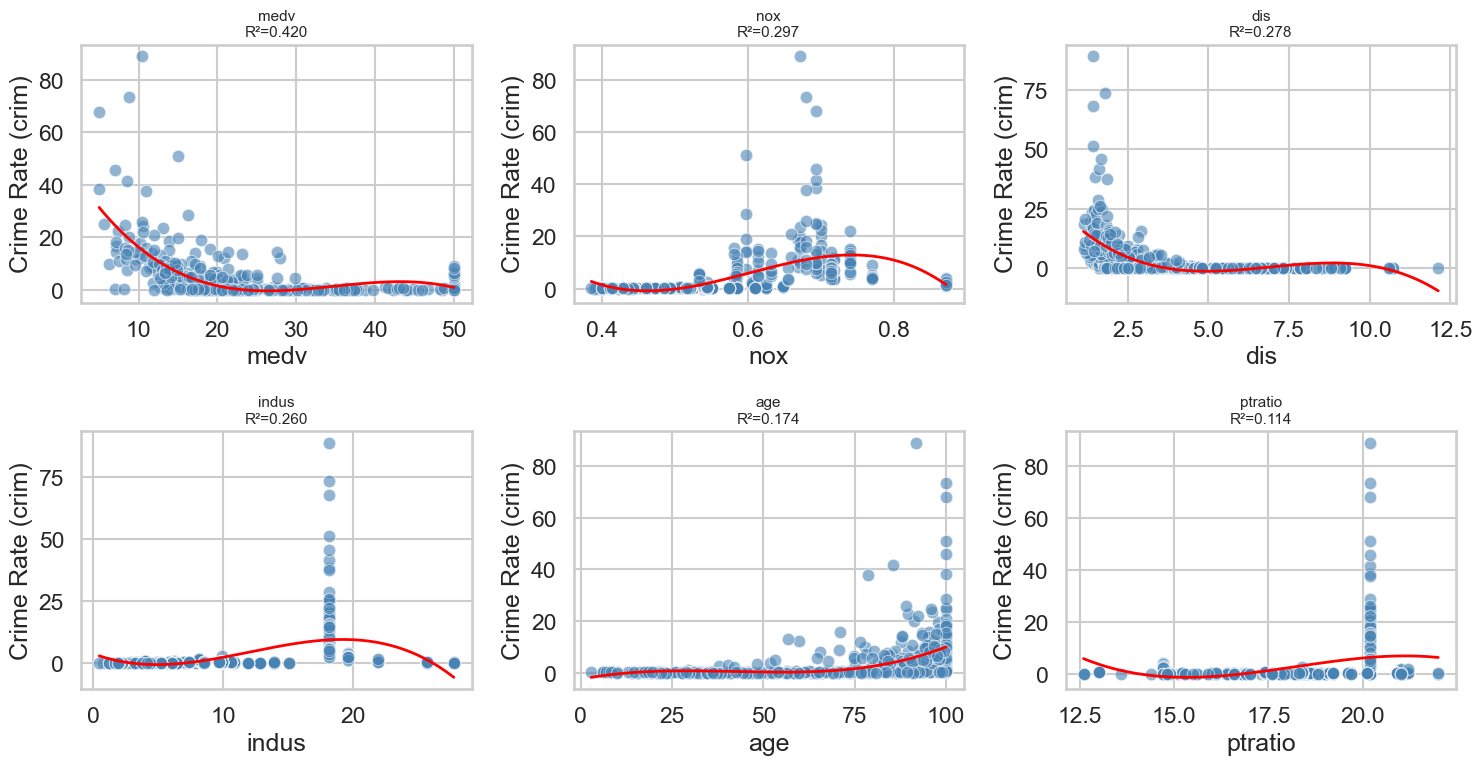

In [26]:
sns.set(style="whitegrid", context="talk")

n = len(nonlinear_vars)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

for i, col in enumerate(nonlinear_vars["Predictor"]):
    x = boston[col]
    X_plot = sm.add_constant(
        pd.DataFrame({"X": x, "X2": x**2, "X3": x**3})
    )
    model_plot = sm.OLS(y, X_plot).fit()

    x_sorted = np.linspace(x.min(), x.max(), 200)
    y_pred = model_plot.predict(sm.add_constant(
        pd.DataFrame({"X": x_sorted, "X2": x_sorted**2, "X3": x_sorted**3})
    ))

    sns.scatterplot(x=x, y=y, color="steelblue", alpha=0.6, ax=axes[i])
    axes[i].plot(x_sorted, y_pred, color="red", linewidth=2)
    axes[i].set_title(f"{col}\nR²={model_plot.rsquared:.3f}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Crime Rate (crim)")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

medv, nox, dis, medv, indus, age and ptratio show statistically significant quadratic or cubic terms, they have non-linear associations with the per capita crime rate. others predictors keep linear relationship with crime rate.